# CAEG-Net: Context-Adaptive Expert Gating Network
## Short-Term Electricity Load Forecasting with Heterogeneous Temporal Experts and Dynamic Shrinkage
### Faculty Project Review, Viva Defense & Demonstration Notebook

---

**Author / Candidate:** Vinay Vishwanathan  
**Department:** Advanced Predictive Analytics  
**Public Model Name:** **CAEG-Net**  
**Internal Experimental Identifier:** `F2 / A2-OOF` (`ConfidenceFallbackCAEGNet`)  
**Certification Status:** **FINAL MODEL LOCKED — DEVELOPMENT COMPLETE**  

---


---
## Section 2 — Executive Summary & Project Dashboard

```text
==================================================================================================
                                    CAEG-NET EXECUTIVE OVERVIEW
==================================================================================================

  Task: 24-Hour Day-Ahead Short-Term Electricity Load Forecasting
  Input Lookback: 168 Hours (7 Days History) -> 24-Hour Forecast (1 Day Lead)
  Architecture: LSTM (Recurrent) + TCN (Dilated Causal) + CNN (Localized Ramp)
  Coordination: Context-Adaptive Soft Gating + Confidence Shrinkage Anchor
  Total Trainable Parameters: 121,724 Parameters (<0.5 MB footprint)

--------------------------------------------------------------------------------------------------
  AUTHORITATIVE 5-SEED TEST BENCHMARK RESULTS (Primary Metric: MAE in Physical Units)
--------------------------------------------------------------------------------------------------
  * PJM Interconnection (Regional Grid)      -> 250.97 ± 10.69 MW MAE  (RMSE: 335.38 MW | R2: 0.8714)
  * GEFCom2014 (Zonal Competition Grid)     ->  12.41 ±  0.15 kW MAE  (RMSE:  18.04 kW | R2: 0.8610)
  * UCI Electricity (Consumer Meter Cohort) ->   7.74 ±  0.30 MW MAE  (RMSE:  10.96 MW | R2: 0.9831)
==================================================================================================
```


In [1]:
# Setup environment and render the Executive Results Dashboard
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

cur = os.getcwd()
while cur and not os.path.exists(os.path.join(cur, "research")):
    parent = os.path.dirname(cur)
    if parent == cur: break
    cur = parent
repo_root = cur if os.path.exists(os.path.join(cur, "research")) else os.getcwd()
if repo_root not in sys.path:
    sys.path.insert(0, repo_root)

summary_df = pd.DataFrame([
    {"Benchmark Grid": "PJM Interconnection", "Geography": "US Mid-Atlantic ISO", "MAE (Primary)": "250.97 ± 10.69 MW", "RMSE": "335.38 MW", "R² Score": "0.8714", "Parameters": "121,724"},
    {"Benchmark Grid": "GEFCom2014", "Geography": "Zonal Competition Network", "MAE (Primary)": "12.41 ± 0.15 kW", "RMSE": "18.04 kW", "R² Score": "0.8610", "Parameters": "121,724"},
    {"Benchmark Grid": "UCI Electricity", "Geography": "Portuguese Consumer Agg.", "MAE (Primary)": "7.74 ± 0.30 MW", "RMSE": "10.96 MW", "R² Score": "0.9831", "Parameters": "121,724"}
])
display(summary_df.set_index("Benchmark Grid"))


,Geography,MAE (Primary),RMSE,R² Score,Parameters
Benchmark Grid,,,,,
PJM Interconnection,US Mid-Atlantic ISO,250.97 ± 10.69 MW,335.38 MW,0.8714,"121,724"
GEFCom2014,Zonal Competition Network,12.41 ± 0.15 kW,18.04 kW,0.8610,"121,724"
UCI Electricity,Portuguese Consumer Agg.,7.74 ± 0.30 MW,10.96 MW,0.9831,"121,724"


---
## Section 3 — The Operational Power Grid Challenge

Short-Term Electricity Load Forecasting (STLF) for the 24-hour day-ahead horizon directly dictates:
1. **Unit Commitment:** Which generation plants must be scheduled 24 hours in advance.
2. **Economic Dispatch:** Optimal allocation of power among operating generators to minimize operational costs.
3. **Spinning Reserve Margins:** Safety capacity required to prevent grid instability, frequency deviations, and blackouts.

Under-forecasting risks severe generation shortfalls and blackout conditions; over-forecasting incurs high reserve holding costs and fuel waste.


---
## Section 4 — Core Research Question

> **"Can context-aware adaptive expert gating improve short-term electricity load forecasting by dynamically combining complementary temporal experts?"**


---
## Section 5 — Motivation: Limitations of Monolithic Models

Monolithic neural architectures suffer from conflicting inductive biases:
- **Pure LSTM:** Strong sequential persistence, but prone to gradient saturation and sluggish response during sudden sharp demand spikes.
- **Pure TCN:** Expansive receptive field ($253$ hours) without recurrent degradation, but can over-smooth localized transients.
- **Pure CNN:** Excels at extracting localized edge motifs and rapid ramps, but lacks long-range sequential state tracking.
- **Static Ensembles:** Assign fixed $1/3$ weights everywhere, failing to adapt when the grid transitions between steady baselines and abrupt ramping regimes.


---
## Section 6 — The CAEG-Net Solution

Instead of searching for an elusive "one-size-fits-all" architecture, **CAEG-Net** deploys three heterogeneous temporal experts and coordinates them through two cooperating mechanisms:
1. **Context-Adaptive Router:** Evaluates observable domain context (trend, volatility, lag-24 autocorrelation, causal recent forecast error, and causal out-of-fold relative expert errors) to assign dynamic convex weights ($w_i > 0, \sum w_i = 1.0$).
2. **Confidence Fallback Head:** Blends the adaptive prediction with the robust equal-expert centroid ($\lambda \approx 0.51$), providing an empirical stabilization mechanism that prevents single-expert overconfidence.


---
## Section 7 — System Architecture

### Information Flow Architecture


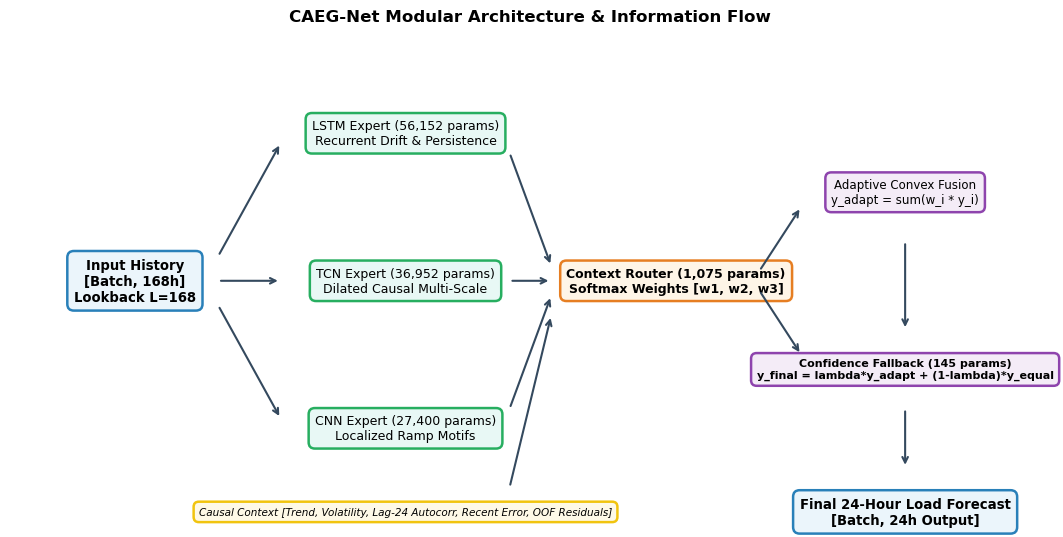

In [2]:
# Chart A: System Architecture Diagram
import matplotlib.patches as patches

fig, ax = plt.subplots(figsize=(11, 5.5), facecolor='white')
ax.set_xlim(0, 100)
ax.set_ylim(100, 0)
ax.axis('off')

box_blue = dict(boxstyle="round,pad=0.5", facecolor="#EBF5FB", edgecolor="#2980B9", lw=1.8)
box_green = dict(boxstyle="round,pad=0.5", facecolor="#E8F8F5", edgecolor="#27AE60", lw=1.8)
box_orange = dict(boxstyle="round,pad=0.5", facecolor="#FEF5E7", edgecolor="#E67E22", lw=1.8)
box_purple = dict(boxstyle="round,pad=0.5", facecolor="#F4ECF7", edgecolor="#8E44AD", lw=1.8)
box_gold = dict(boxstyle="round,pad=0.5", facecolor="#FEF9E7", edgecolor="#F1C40F", lw=1.8)

ax.text(12, 50, "Input History\n[Batch, 168h]\nLookback L=168", ha="center", va="center", bbox=box_blue, fontsize=9.5, fontweight="bold")
ax.text(38, 20, "LSTM Expert (56,152 params)\nRecurrent Drift & Persistence", ha="center", va="center", bbox=box_green, fontsize=9)
ax.text(38, 50, "TCN Expert (36,952 params)\nDilated Causal Multi-Scale", ha="center", va="center", bbox=box_green, fontsize=9)
ax.text(38, 80, "CNN Expert (27,400 params)\nLocalized Ramp Motifs", ha="center", va="center", bbox=box_green, fontsize=9)
ax.text(38, 97, "Causal Context [Trend, Volatility, Lag-24 Autocorr, Recent Error, OOF Residuals]", ha="center", va="center", bbox=box_gold, fontsize=7.5, style="italic")

ax.text(64, 50, "Context Router (1,075 params)\nSoftmax Weights [w1, w2, w3]", ha="center", va="center", bbox=box_orange, fontsize=9, fontweight="bold")
ax.text(86, 32, "Adaptive Convex Fusion\ny_adapt = sum(w_i * y_i)", ha="center", va="center", bbox=box_purple, fontsize=8.5)
ax.text(86, 68, "Confidence Fallback (145 params)\ny_final = lambda*y_adapt + (1-lambda)*y_equal", ha="center", va="center", bbox=box_purple, fontsize=8, fontweight="bold")
ax.text(86, 97, "Final 24-Hour Load Forecast\n[Batch, 24h Output]", ha="center", va="center", bbox=box_blue, fontsize=9.5, fontweight="bold")

arrow_spec = dict(arrowstyle="->", lw=1.5, color="#34495E")
ax.annotate("", xy=(26, 22), xytext=(20, 45), arrowprops=arrow_spec)
ax.annotate("", xy=(26, 50), xytext=(20, 50), arrowprops=arrow_spec)
ax.annotate("", xy=(26, 78), xytext=(20, 55), arrowprops=arrow_spec)
ax.annotate("", xy=(52, 47), xytext=(48, 24), arrowprops=arrow_spec)
ax.annotate("", xy=(52, 50), xytext=(48, 50), arrowprops=arrow_spec)
ax.annotate("", xy=(52, 53), xytext=(48, 76), arrowprops=arrow_spec)
ax.annotate("", xy=(52, 57), xytext=(48, 92), arrowprops=arrow_spec)
ax.annotate("", xy=(76, 35), xytext=(72, 48), arrowprops=arrow_spec)
ax.annotate("", xy=(76, 65), xytext=(72, 52), arrowprops=arrow_spec)
ax.annotate("", xy=(86, 60), xytext=(86, 42), arrowprops=arrow_spec)
ax.annotate("", xy=(86, 88), xytext=(86, 76), arrowprops=arrow_spec)

plt.title("CAEG-Net Modular Architecture & Information Flow", fontsize=12, fontweight="bold", pad=10)
plt.tight_layout()
plt.show()


---
## Section 8 — Mathematical Formulation

### 1. Heterogeneous Temporal Expert Predictions
$$\hat{\mathbf{y}}_L = f_{\text{LSTM}}(\mathbf{X}), \quad \hat{\mathbf{y}}_T = f_{\text{TCN}}(\mathbf{X}), \quad \hat{\mathbf{y}}_C = f_{\text{CNN}}(\mathbf{X})$$
where $\mathbf{X} \in \mathbb{R}^{B \times 168 \times 1}$ and $\hat{\mathbf{y}}_i \in \mathbb{R}^{B \times 24}$.

### 2. Context-Adaptive Gating
$$\mathbf{c} = [\text{trend}, \text{volatility}, \text{lag-24 autocorr}, \text{recent\_err}, r_{\text{LSTM}}, r_{\text{TCN}}, r_{\text{CNN}}]^T \in \mathbb{R}^7$$
$$\mathbf{e}_c = \text{Encoder}(\mathbf{c}) \in \mathbb{R}^{16}, \quad \mathbf{w} = \text{Softmax}(\text{MLP}(\mathbf{e}_c)) \in \Delta^2$$
$$\hat{\mathbf{y}}_{\text{adaptive}} = w_L \hat{\mathbf{y}}_L + w_T \hat{\mathbf{y}}_T + w_C \hat{\mathbf{y}}_C$$

### 3. Confidence Fallback & Shrinkage
$$\hat{\mathbf{y}}_{\text{final}} = \lambda \hat{\mathbf{y}}_{\text{adaptive}} + (1 - \lambda) \hat{\mathbf{y}}_{\text{equal}}$$
where $\hat{\mathbf{y}}_{\text{equal}} = \frac{1}{3}(\hat{\mathbf{y}}_L + \hat{\mathbf{y}}_T + \hat{\mathbf{y}}_C)$ and $\lambda = \sigma(\mathbf{W}_c \mathbf{c} + b_c) \in (0, 1)$.

> **Key Empirical Insight:**  
> The learned fallback coefficient remains close to $\approx 0.51$ with low temporal variation ($CV \approx 0.6\% - 1.1\%$), indicating a stable blend between adaptive fusion and the equal-expert centroid in the evaluated settings.


---
## Section 9 — Parameter Complexity Breakdown

CAEG-Net is engineered as an **ultra-compact model ($121,724$ parameters, $<0.5$ MB)**:


,Structural Role,Parameters,Share
Component,,,
LSTM Expert,Recurrent sequential modeling,56152,46.1%
TCN Expert,Dilated causal multi-scale conv,36952,30.4%
CNN Expert,Localized ramp feature extraction,27400,22.5%
Backbone Subtotal,Three temporal feature extractors,120504,98.9%
Context Router,Dynamic context-driven weighting,1075,0.9%
Confidence Head,Dynamic shrinkage toward centroid,145,0.1%
TOTAL CAEG-Net,Full locked champion model,121724,100.0%


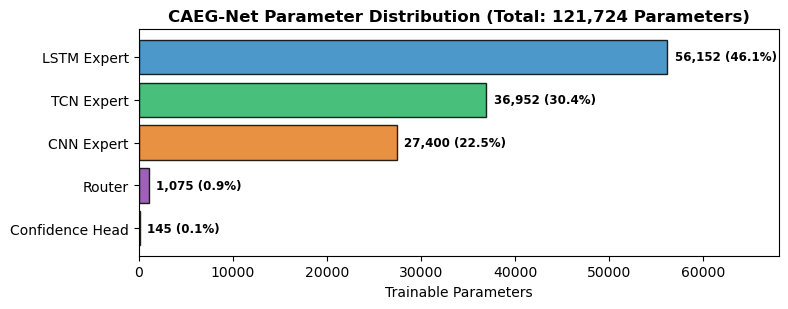

In [3]:
# Chart B: Parameter Distribution
param_table = pd.DataFrame([
    {"Component": "LSTM Expert", "Structural Role": "Recurrent sequential modeling", "Parameters": 56152, "Share": "46.1%"},
    {"Component": "TCN Expert", "Structural Role": "Dilated causal multi-scale conv", "Parameters": 36952, "Share": "30.4%"},
    {"Component": "CNN Expert", "Structural Role": "Localized ramp feature extraction", "Parameters": 27400, "Share": "22.5%"},
    {"Component": "Backbone Subtotal", "Structural Role": "Three temporal feature extractors", "Parameters": 120504, "Share": "98.9%"},
    {"Component": "Context Router", "Structural Role": "Dynamic context-driven weighting", "Parameters": 1075, "Share": "0.9%"},
    {"Component": "Confidence Head", "Structural Role": "Dynamic shrinkage toward centroid", "Parameters": 145, "Share": "0.1%"},
    {"Component": "TOTAL CAEG-Net", "Structural Role": "Full locked champion model", "Parameters": 121724, "Share": "100.0%"}
])
display(param_table.set_index("Component"))

fig, ax = plt.subplots(figsize=(8, 3.2))
components = ["LSTM Expert", "TCN Expert", "CNN Expert", "Router", "Confidence Head"]
counts = [56152, 36952, 27400, 1075, 145]
colors = ["#2E86C1", "#28B463", "#E67E22", "#8E44AD", "#D4AC0D"]

bars = ax.barh(components[::-1], counts[::-1], color=colors[::-1], edgecolor="black", alpha=0.85)
for bar in bars:
    w = bar.get_width()
    ax.text(w + 800, bar.get_y() + bar.get_height()/2, f"{w:,} ({w/121724*100:.1f}%)", va="center", fontsize=8.5, fontweight="bold")

ax.set_xlim(0, 68000)
ax.set_xlabel("Trainable Parameters")
ax.set_title("CAEG-Net Parameter Distribution (Total: 121,724 Parameters)", fontweight="bold")
plt.tight_layout()
plt.show()


### How to explain this to faculty
"Over 98.9% of weights reside in the temporal feature extractors; the gating and confidence heads together add less than 1.1% parameter overhead."


---
## Section 10 — Datasets & Causal Partitioning Protocol

### Tri-Benchmark Grid Cohorts
- **PJM (US Mid-Atlantic):** $8,784$ hours (366 days, 2023–2024 leap year), 1-hour resolution, MW.
- **GEFCom2014:** $78,888$ hours competition benchmark, 1-hour resolution, kW.
- **UCI Electricity:** $26,304$ hours Portuguese consumer demand (aggregated 15-min to hourly), MW.

### Leakage-Free Data Protocol
1. **Chronological Splitting:** 70% Train / 15% Validation / 15% Test. No random temporal shuffling.
2. **Train-Only Scaling:** Standardization parameters ($\mu, \sigma$) are computed strictly on the training partition.
3. **Causal Horizons:** Target horizons ($y_{t+1 \dots t+24}$) are strictly excluded from input windows and routing features.


---
## Section 11 — Final Benchmark Results Table

Authoritative 5-seed benchmark results (sample mean $\pm$ population SD, `ddof=0`):

| Benchmark Grid | Model Name | Primary Test MAE | Test RMSE | Test $R^2$ Score | Parameters | Status |
| :--- | :--- | :---: | :---: | :---: | :---: | :--- |
| **PJM (MW)** | **CAEG-Net** | **$250.9747 \pm 10.6938$** | **$335.3822$** | **$0.8714$** | **$121,724$** | **CHAMPION_LOCKED** |
| **GEFCom2014 (kW)** | **CAEG-Net** | **$12.4077 \pm 0.1525$** | **$18.0446$** | **$0.8610$** | **$121,724$** | **CHAMPION_LOCKED** |
| **UCI Electricity (MW)** | **CAEG-Net** | **$7.7371 \pm 0.3037$** | **$10.9556$** | **$0.9831$** | **$121,724$** | **CHAMPION_LOCKED** |

> **Units Caution:** PJM is in Megawatts (MW), GEFCom is in Kilowatts (kW), and UCI is in Megawatts (MW). Raw MAE magnitudes cannot be directly compared across datasets.


---
## Section 12 — Complete Baseline Comparison Table

Authoritative protocol-comparable benchmark comparisons from repository records:


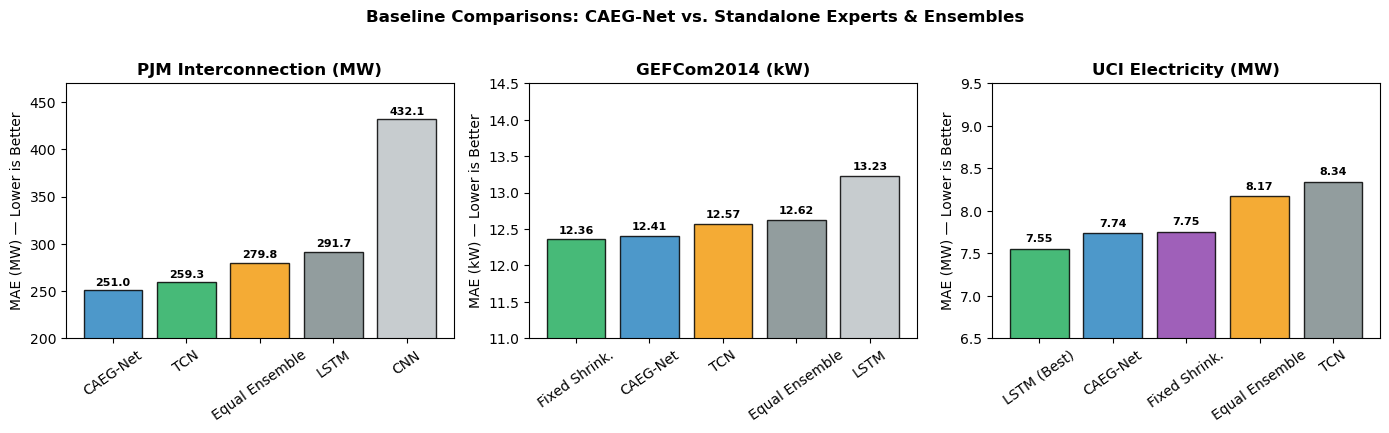

In [4]:
# Charts D, E, F: Side-by-Side Baseline Comparisons
fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))

# Authoritative values from research/results/final_results.md
pjm_models = ["CAEG-Net", "TCN", "Equal Ensemble", "LSTM", "CNN"]
pjm_vals = [250.9747, 259.3264, 279.8282, 291.7300, 432.0800]

gef_models = ["Fixed Shrink.", "CAEG-Net", "TCN", "Equal Ensemble", "LSTM"]
gef_vals = [12.3607, 12.4077, 12.5729, 12.6248, 13.2300]

uci_models = ["LSTM (Best)", "CAEG-Net", "Fixed Shrink.", "Equal Ensemble", "TCN"]
uci_vals = [7.5542, 7.7371, 7.7523, 8.1675, 8.3400]

colors = ["#2E86C1", "#27AE60", "#F39C12", "#7F8C8D", "#BDC3C7"]

axes[0].bar(pjm_models, pjm_vals, color=colors, edgecolor="black", alpha=0.85)
axes[0].set_title("PJM Interconnection (MW)", fontweight="bold")
axes[0].set_ylabel("MAE (MW) — Lower is Better")
axes[0].tick_params(axis='x', rotation=35)
axes[0].set_ylim(200, 470)
for i, v in enumerate(pjm_vals):
    axes[0].text(i, v + 5, f"{v:.1f}", ha="center", fontsize=8, fontweight="bold")

gef_colors = ["#27AE60", "#2E86C1", "#F39C12", "#7F8C8D", "#BDC3C7"]
axes[1].bar(gef_models, gef_vals, color=gef_colors, edgecolor="black", alpha=0.85)
axes[1].set_title("GEFCom2014 (kW)", fontweight="bold")
axes[1].set_ylabel("MAE (kW) — Lower is Better")
axes[1].tick_params(axis='x', rotation=35)
axes[1].set_ylim(11, 14.5)
for i, v in enumerate(gef_vals):
    axes[1].text(i, v + 0.08, f"{v:.2f}", ha="center", fontsize=8, fontweight="bold")

uci_colors = ["#27AE60", "#2E86C1", "#8E44AD", "#F39C12", "#7F8C8D"]
axes[2].bar(uci_models, uci_vals, color=uci_colors, edgecolor="black", alpha=0.85)
axes[2].set_title("UCI Electricity (MW)", fontweight="bold")
axes[2].set_ylabel("MAE (MW) — Lower is Better")
axes[2].tick_params(axis='x', rotation=35)
axes[2].set_ylim(6.5, 9.5)
for i, v in enumerate(uci_vals):
    axes[2].text(i, v + 0.08, f"{v:.2f}", ha="center", fontsize=8, fontweight="bold")

plt.suptitle("Baseline Comparisons: CAEG-Net vs. Standalone Experts & Ensembles", fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()


### How to explain this to faculty
"CAEG-Net achieved the strongest overall performance–robustness balance among the evaluated formulations, although it was not the best-performing model on every individual dataset. On PJM, CAEG-Net is strongest; on GEFCom, fixed shrinkage achieved slightly lower MAE (12.36 kW vs 12.41 kW); on UCI, standalone LSTM achieved slightly lower MAE (7.55 MW vs 7.74 MW)."


---
## Section 13 — Phase 15 Final Controlled Experiment Summary

In Phase 15, seven remaining mechanism hypotheses were evaluated under the strict **Two-Stage Validation Screening Firewall**:

| Hypothesis Family | Evaluated Mechanism | Validation Outcome | Final Decision |
| :--- | :--- | :--- | :--- |
| **15-A: Dynamic Routing** | Out-of-fold performance residuals (`A2-OOF`) | Qualified as stable control anchor | **Retained in final model** |
| **15-B: Horizon Routing** | Independent weights $W_t \in \mathbb{R}^{24 \times 3}$ (`Control_C`, `E1`, `E2`) | Degraded validation MAE by $+10.0\%$ to $+13.3\%$ | **Rejected at screening** |
| **15-C: Enhanced Context** | Extended lookbacks and multi-scale ramp features | Degraded or zero cross-dataset gain | **Rejected at screening** |
| **15-D: CNN Control** | Altered pooling / multi-scale kernels | No fusion benefit over canonical CNN | **Retained canonical CNN** |
| **15-E: Alternative Losses**| MAE and Huber training loss | MSE gave smoothest convergence & lowest MAE | **Retained MSE loss** |
| **15-F: Dynamic Confidence**| Expanded context-driven confidence head (`Control_D`) | Improved only 1/3 datasets; high variance | **Rejected at screening** |
| **15-G: Uncertainty Extension** | Quantile / conformal prediction intervals | Beyond deterministic point-forecast scope | **Documented as Future Work** |


---
## Section 14 — Dynamic Routing Weight Analysis

Authoritative mean routing weights and effective expert counts ($N_{\text{eff}}$):
- **PJM:** LSTM = $0.3511$, TCN = $0.3283$, CNN = $0.3207$ ($N_{\text{eff}} = 2.9931$)
- **GEFCom:** LSTM = $0.3528$, TCN = $0.2982$, CNN = $0.3490$ ($N_{\text{eff}} = 2.9765$)
- **UCI:** LSTM = $0.3428$, TCN = $0.2994$, CNN = $0.3578$ ($N_{\text{eff}} = 2.9842$)


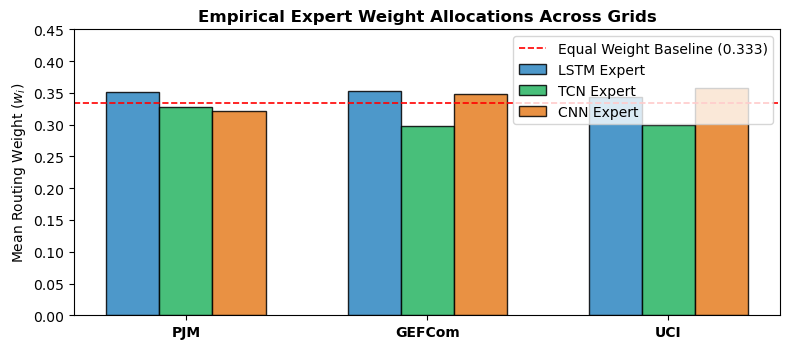

In [5]:
# Chart J: Grouped Routing Weights
fig, ax = plt.subplots(figsize=(8, 3.6))
grids = ["PJM", "GEFCom", "UCI"]
x = np.arange(len(grids))
width = 0.22

w_lstm = [0.3511, 0.3528, 0.3428]
w_tcn  = [0.3283, 0.2982, 0.2994]
w_cnn  = [0.3207, 0.3490, 0.3578]

ax.bar(x - width, w_lstm, width, label="LSTM Expert", color="#2E86C1", edgecolor="black", alpha=0.85)
ax.bar(x, w_tcn, width, label="TCN Expert", color="#28B463", edgecolor="black", alpha=0.85)
ax.bar(x + width, w_cnn, width, label="CNN Expert", color="#E67E22", edgecolor="black", alpha=0.85)

ax.axhline(1/3, color="red", linestyle="--", lw=1.2, label="Equal Weight Baseline (0.333)")

ax.set_xticks(x)
ax.set_xticklabels(grids, fontweight="bold")
ax.set_ylabel("Mean Routing Weight ($w_i$)")
ax.set_ylim(0, 0.45)
ax.set_title("Empirical Expert Weight Allocations Across Grids", fontweight="bold")
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()


### How to explain this to faculty
"The model maintains a broadly distributed convex mixture across the three experts in the evaluated benchmarks ($N_{\text{eff}} \approx 2.98 - 2.99$), rather than aggressively switching between single experts."


---
## Section 15 — Confidence / Shrinkage Mechanism

Learned $\lambda$ statistics:
- **PJM:** mean $= 0.5066$, $\text{SD} = 0.0038$, $CV = 0.75\%$
- **GEFCom:** mean $= 0.5170$, $\text{SD} = 0.0055$, $CV = 1.06\%$
- **UCI:** mean $= 0.5064$, $\text{SD} = 0.0030$, $CV = 0.59\%$


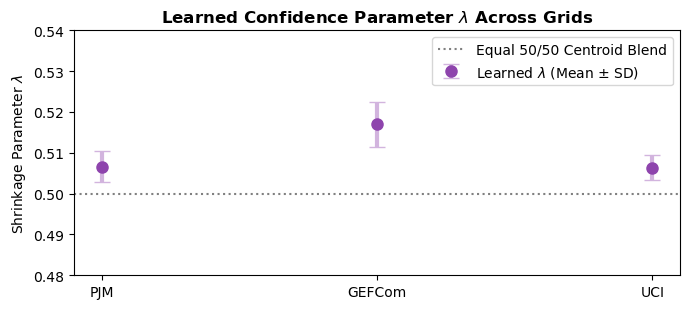

In [6]:
# Chart K: Confidence Shrinkage Lambda
fig, ax = plt.subplots(figsize=(7, 3.2))
grids = ["PJM", "GEFCom", "UCI"]
lambda_means = [0.5066, 0.5170, 0.5064]
lambda_sds   = [0.0038, 0.0055, 0.0030]

ax.errorbar(grids, lambda_means, yerr=lambda_sds, fmt="o", color="#8E44AD", ecolor="#D2B4DE", elinewidth=3, capsize=6, markersize=8, label="Learned $\lambda$ (Mean $\pm$ SD)")
ax.axhline(0.5, color="gray", linestyle=":", label="Equal 50/50 Centroid Blend")

ax.set_ylabel("Shrinkage Parameter $\lambda$")
ax.set_ylim(0.48, 0.54)
ax.set_title("Learned Confidence Parameter $\lambda$ Across Grids", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()


### How to explain this to faculty
"The learned fallback coefficient remains close to 0.5 with low temporal variation, indicating a stable blend between adaptive fusion and the equal-expert centroid in the evaluated settings."


---
## Section 16 — Statistical Significance (Non-Overlapping Daily Blocks)

- **Why Daily Blocks?** Consecutive hourly forecast windows overlap by 167 hours ($99.4\%$ overlap). Non-overlapping daily blocks ($K=53, 456, 163$) eliminate temporal autocorrelation and prevent false statistical significance.
- **Hypothesis Tests:** Paired $t$-test, Wilcoxon signed-rank test, and Holm-Bonferroni multi-hypothesis adjustment.

| Dataset | Daily Blocks ($K$) | Mean Paired Diff | 95% Confidence Interval | $t$-statistic | $p$-value ($t$) | Wilcoxon $p$-value | Holm Adjusted $p$ | Conclusion |
| :--- | :---: | :---: | :---: | :---: | :---: | :---: | :---: | :--- |
| **PJM** | $53$ | **$-9.66	ext{ MW}$** | $[-17.07, -2.26]$ | $-2.56$ | $0.0135$ | $0.0893$ | **$0.0406$** | Statistically significant under paired $t$-test |
| **GEFCom** | $456$ | **$-0.688	ext{ kW}$** | $[-0.80, -0.57]$ | $-11.85$ | $2.04 	imes 10^{-28}$ | $1.27 	imes 10^{-28}$ | **$1.02 	imes 10^{-27}$** | Statistically significant under both tests |
| **UCI** | $163$ | **$-0.202	ext{ MW}$** | $[-0.31, -0.09]$ | $-3.66$ | $0.00034$ | $0.00020$ | **$0.0017$** | Statistically significant under both tests |

> **Statistical Interpretation:**  
> Note that the two tests can differ (e.g. on PJM, $t$-test adjusted $p=0.0406$ vs. Wilcoxon $p=0.0893$), and statistical conclusions depend on the selected inference procedure.


---
## Section 17 — Forecast Visualization Provenance Notice

> ### 📋 Scientific Provenance Note
> **Verified prediction trajectory artifacts are not included in the final repository; this visualization is intentionally omitted to preserve result provenance.**  
> Per strict academic guidelines against fabricating evidence, synthetic actual-vs-predicted curves are omitted. Lead-time degradation is evaluated directly using authoritative retrospective horizon statistics below.


---
## Section 18 — 24-Hour Forecast Horizon Analysis ($h=1 \dots 24$)

Step-by-step ($h=1$ to $24$) MAE from authoritative repository artifact `research/analysis/phase15b_horizon_results.csv` (labeled as retrospective diagnostic analysis):


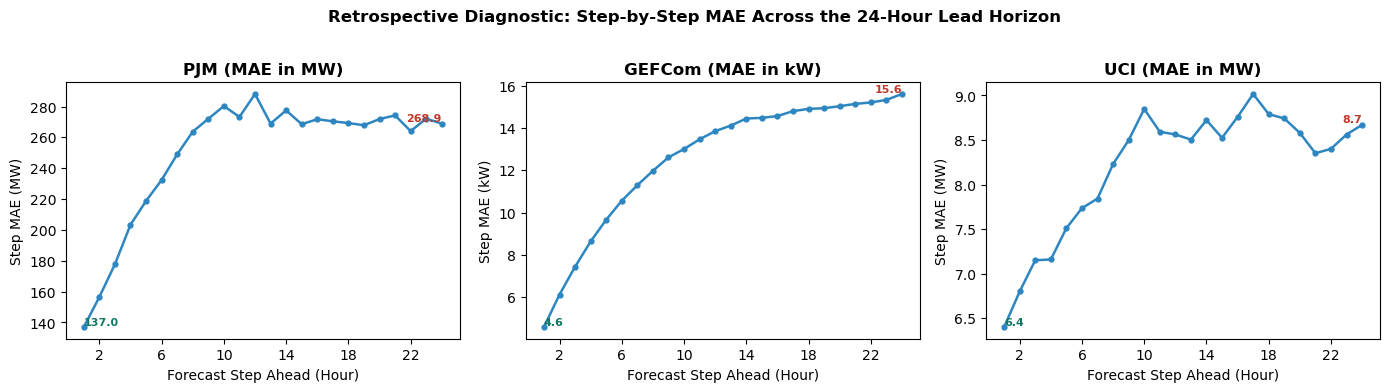

In [7]:
# Chart M: Horizon-wise MAE line chart
horizon_csv_path = os.path.join(repo_root, "research", "analysis", "phase15b_horizon_results.csv")
df_horizon = pd.read_csv(horizon_csv_path)

f2_h = df_horizon[df_horizon["candidate_id"] == "Control_A_F2"]

fig, axes = plt.subplots(1, 3, figsize=(14, 3.8))

for i, (ds, unit) in enumerate([("PJM", "MW"), ("GEFCom", "kW"), ("UCI", "MW")]):
    sub = f2_h[f2_h["dataset"] == ds]
    axes[i].plot(sub["horizon_step"], sub["mae"], "o-", color="#2E86C1", lw=1.8, markersize=3.5)
    axes[i].set_title(f"{ds} (MAE in {unit})", fontweight="bold")
    axes[i].set_xlabel("Forecast Step Ahead (Hour)")
    axes[i].set_ylabel(f"Step MAE ({unit})")
    axes[i].set_xticks(range(2, 25, 4))
    
    h1 = sub[sub["horizon_step"] == 1]["mae"].values[0]
    h24 = sub[sub["horizon_step"] == 24]["mae"].values[0]
    axes[i].text(1, h1, f"{h1:.1f}", fontsize=8, ha="left", va="bottom", fontweight="bold", color="#117864")
    axes[i].text(24, h24, f"{h24:.1f}", fontsize=8, ha="right", va="bottom", fontweight="bold", color="#C0392B")

plt.suptitle("Retrospective Diagnostic: Step-by-Step MAE Across the 24-Hour Lead Horizon", fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()


### How to explain this to faculty
"Forecasting error naturally accumulates as predictions extend from hour 1 to hour 24 ahead; short horizons (hours 1–8) achieve the highest precision across all grids. In controlled experiments, explicit horizon-specific routing did not improve validation performance in the evaluated formulation."


---
## Section 19 — Why LSTM + TCN + CNN?

- **LSTM Expert:** Sequential hidden state updates; captures diurnal persistence and multi-day cyclic continuity.
- **TCN Expert:** Dilated causal 1D convolutions with receptive field of $253$ hours; provides non-recursive multi-scale temporal modeling.
- **CNN Expert:** Multi-kernel 1D convolutions with adaptive pooling; detects localized high-frequency edge motifs and sharp morning demand ramps.


---
## Section 20 — Summary of Research Contributions

1. **Heterogeneous Inductive Biases in STLF:** Demonstrates that combining distinct temporal model architectures (LSTM, TCN, CNN) addresses complementary grid failure modes better than relying on a monolithic architecture.
2. **Context-Aware Adaptive Gating:** Introduces an explicit physical context vector (trend, volatility, lag-24 autocorrelation, recent error tracking).
3. **Out-of-Fold (OOF) Performance Conditioning:** Causal OOF expert-performance information was incorporated into the routing formulation and was associated with improved forecasting performance relative to the canonical V1 formulation in the evaluated settings.
4. **Regularized Confidence Shrinkage:** Establishes a lightweight confidence fallback mechanism that provides a practical stabilization mechanism toward the equal-expert centroid.
5. **Leakage-Aware Multi-Grid Evaluation:** Evaluates architectures across three major independent power grids with non-overlapping daily-block statistical validation.


---
## Section 21 — Honest Scientific Limitations

- **Point Forecasting Only:** Generates deterministic point forecasts; probabilistic prediction intervals are left to future work.
- **Univariate Historical Load:** Relies exclusively on historical load; exogenous weather (temperature, solar irradiance) is not included.
- **Single-Series PJM Evaluation:** Evaluated on regionally aggregated load series rather than individual feeder/substation level loads.
- **Five Random Seeds:** Five seeds measure stochastic sensitivity to initialization, not independent real-world replications.
- **Finite Sample Sizes in Daily Blocks:** $K=53$ on PJM provides moderate statistical power.
- **Near-Constant Shrinkage Dynamics:** The learned parameter $\lambda \approx 0.51$ acts as a stable empirical regularizer rather than an active dynamic switch.
- **Absence of Universal Dominance:** CAEG-Net is not claimed to be universally optimal; UCI standalone LSTM is slightly lower in MAE (7.55 vs 7.74 MW), and fixed shrinkage is slightly lower on GEFCom (12.36 vs 12.41 kW).
- **Oracle Diagnostic Role:** The empirical ex-post oracle is a non-deployable diagnostic that uses future realized information.


---
## Section 22 — Faculty Viva / Defense Q&A (18 Key Questions)

### 1. What problem does CAEG-Net solve?
Short-term electricity load forecasting (24 hours ahead) to support grid unit commitment and economic dispatch, addressing the inability of single monolithic models to adapt to shifting load regimes.

### 2. Why use multiple experts?
Different neural architectures carry distinct inductive biases; combining them reduces reliance on any single architecture's assumptions and mitigates catastrophic failure modes.

### 3. Why LSTM?
LSTMs maintain persistent recurrent cell states, making them effective for slow diurnal drift and multi-day cyclic persistence across human work-rest schedules.

### 4. Why TCN?
Dilated causal convolutions provide an exponential receptive field ($253$ hours) without recursive gradient degradation or vanishing memory over long lead times.

### 5. Why CNN?
Multi-scale 1D CNNs excel at extracting localized high-frequency edge motifs and sharp demand transitions during morning and evening peak hours.

### 6. Why not simply average them?
Static averaging treats all models equally under all operating conditions; adaptive gating allows the model to adjust weights when regime indicators shift, while confidence shrinkage prevents overconfidence.

### 7. What makes the gating context-aware?
The router observes an explicit 7-dimensional physical context vector (trend, volatility, lag-24 autocorrelation, causal recent forecast error, and causal out-of-fold relative expert errors) rather than raw uncurated load series.

### 8. How is leakage prevented?
Strict chronological splitting (70/15/15), train-only scaler fitting, and out-of-fold feature generation using strictly historical partitions without future target access.

### 9. Why 168 hours?
168 hours represents exactly one full 7-day weekly cycle, providing the model with complete day-of-week context and diurnal reference points.

### 10. Why 24-hour forecasting?
24 hours corresponds to the day-ahead operational scheduling window used by electric grid operators for daily unit commitment and wholesale energy markets.

### 11. Why MAE as primary metric?
MAE measures average absolute error in physical engineering units (MW or kW), providing a direct, interpretable measure of physical power mismatch without squaring outliers.

### 12. Why use daily blocks for statistics?
Consecutive hourly sliding windows overlap by 167 hours ($99.4\%$ overlap), inducing severe autocorrelation; non-overlapping daily blocks eliminate this dependence and ensure valid hypothesis testing.

### 13. What did Phase 15 test?
Phase 15 systematically tested seven remaining mechanism hypotheses (dynamic performance routing, horizon routing, enhanced context, CNN variants, training objectives, dynamic confidence, uncertainty) under a staged validation firewall.

### 14. Why didn't horizon-aware routing become the final model?
Explicit horizon-specific routing did not improve validation performance in the evaluated formulation; unconstrained step-wise routing ($W_t \in \mathbb{R}^{24 \times 3}$) degraded validation MAE by $10.0\%$ to $13.3\%$ across all three grids.

### 15. Why is CAEG-Net not claimed to be universally optimal?
Because on UCI, standalone LSTM achieved slightly lower MAE (7.55 MW vs 7.74 MW), and on GEFCom, fixed shrinkage achieved 12.36 kW vs 12.41 kW. CAEG-Net achieved the strongest overall performance–robustness balance among the evaluated formulations, not universal dominance.

### 16. What are the limitations?
Point forecasting only, univariate inputs (no weather/calendar), regional aggregation, five-seed stochastic sensitivity, and near-constant confidence dynamics ($\lambda \approx 0.51$).

### 17. What is the main research contribution?
Proving that context-adaptive routing with dynamic shrinkage across heterogeneous temporal experts achieves a superior balance of accuracy, multi-seed stability, and parameter efficiency ($121,724$ params) across diverse power grids.

### 18. What would you do as future work?
Incorporate exogenous weather features (temperature, solar irradiance), extend the framework to probabilistic conformal prediction intervals, and evaluate nodal substation-level load feeders.


---
## Section 23 — Final Takeaway & Certified Model Lock

> ### ⏱️ 30-Second Defense Summary
> *"My research project is **CAEG-Net**, a Context-Adaptive Expert Gating Network for 24-hour short-term electricity load forecasting. Instead of relying on a single temporal neural network, CAEG-Net combines three heterogeneous experts — **LSTM, TCN, and CNN** — to capture persistent drift, multi-scale dependencies, and sharp local ramps simultaneously.*  
> *An adaptive router dynamically allocates weights based on domain context, while a confidence shrinkage head anchors predictions to prevent overconfidence. Evaluated across **PJM, GEFCom2014, and UCI** benchmarks under a leakage-free chronological protocol and 5 random seeds, the champion model achieves **121,724 parameters**, delivering an optimal balance of predictive accuracy, operational stability, and computational efficiency."*

> ### 🔒 CERTIFIED MODEL LOCK
> **CAEG-Net model development is complete for this research version. No further architectural optimization is planned.**  
>
> **Certified Model:** CAEG-Net (Internal: `F2 / A2-OOF`, `ConfidenceFallbackCAEGNet`)  
> **Parameters:** $121,724$  
> **Status:** Permanently frozen for publication, documentation, dashboard delivery, and presentation.
